<a href="https://colab.research.google.com/github/Wilson1994/DTA-2026/blob/main/ML/LinearRegression_DTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#import sklearn

# Щоб результати були однаковими щоразу (відтворюваність)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Бібліотеки готові ✅")

Бібліотеки готові ✅


В данном блоке кода была выполнена подготовка рабочего окружения для анализа данных. Были подключены основные библиотеки: NumPy, Pandas для работы с таблицами и Matplotlib для визуализации данных. Для обеспечения воспроизводимости результатов был зафиксирован генератор случайных чисел (seed = 42). Также были настроены параметры отображения таблиц в Pandas, чтобы данные выводились более удобно и наглядно. В конце была выполнена проверка успешной загрузки всех необходимых библиотек.

У реальній роботі завантажте CSV через `pd.read_csv("file.csv")`.

**Генеруємо дані**  
Створюємо таблицю з ознаками й «справжньою» ціною (з невеликим випадковим шумом, як у житті).

In [2]:
n = 1000  # скільки квартир

area      = np.random.normal(60, 20, n).clip(20, 140)        # площа, м²
rooms     = np.clip(np.round(area / 25 + np.random.normal(0, 0.6, n)), 1, 5)  # кімнати
floor     = np.random.randint(1, 25, n)                      # поверх
dist_km   = np.random.exponential(5, n).clip(0.3, 25)        # відстань до центру, км
age_years = np.random.randint(0, 60, n)                      # вік будинку, років

# "Справжня" логіка ціни (у тис. $) — у житті її НЕ знаємо, модель має її відкрити:
price = (
    40                       # базова
    + area * 1.8             # кожен м² додає
    + rooms * 5              # кожна кімната
    + floor * 0.4            # трохи за поверх
    - dist_km * 3.0          # далі від центру — дешевше
    - age_years * 0.5        # старіший будинок — дешевше
    + np.random.normal(0, 12, n)   # шум: усе інше, що ми не врахували
).clip(20, None)

df = pd.DataFrame({
    "area": area.round(1),
    "rooms": rooms.astype(int),
    "floor": floor,
    "dist_km": dist_km.round(1),
    "age_years": age_years,
    "price": price.round(1),
})

df.head()

,area,rooms,floor,dist_km,age_years,price
0,69.9,4,6,2.6,14,172.1
1,57.2,3,11,6.4,30,122.8
2,73.0,3,3,2.4,54,146.3
3,90.5,3,8,3.4,13,217.6
4,55.3,3,3,2.8,10,165.2


В данном блоке был создан искусственный набор данных о квартирах, состоящий из 1000 записей. Для каждой квартиры были случайным образом сгенерированы основные характеристики: площадь, количество комнат, этаж, расстояние до центра города и возраст дома. Затем на основе этих параметров была рассчитана стоимость квартиры по заранее заданной формуле, в которой учитывается влияние каждого признака на цену, а также добавлен случайный шум для большей реалистичности данных. После этого все признаки были объединены в таблицу Pandas DataFrame.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   area       1000 non-null   float64
 1   rooms      1000 non-null   int64  
 2   floor      1000 non-null   int64  
 3   dist_km    1000 non-null   float64
 4   age_years  1000 non-null   int64  
 5   price      1000 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 47.0 KB


С помощью метода df.info() была получена сводная информация о DataFrame

In [4]:
print(f"Размер таблицы: {df.shape[0]} рядов х {df.shape[1]} столбцов")

print("\nЕсть ли пропуллкии?")
print(df.isna().sum())
df.describe().round(2)

Размер таблицы: 1000 рядов х 6 столбцов

Есть ли пропуллкии?
area         0
rooms        0
floor        0
dist_km      0
age_years    0
price        0
dtype: int64


,area,rooms,floor,dist_km,age_years,price
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,60.49,2.48,12.69,4.96,30.39,136.25
std,19.33,0.95,7.00,4.71,17.23,44.99
min,20.00,1.00,1.00,0.30,0.00,20.00
25%,47.08,2.00,6.00,1.50,16.00,104.15
50%,60.50,2.00,13.00,3.60,30.00,136.75
75%,73.00,3.00,19.00,7.00,45.25,165.45
max,137.10,5.00,24.00,25.00,59.00,282.40


В этом шаге я посмотрел на размер таблицы, чтобы понять сколько у нас данных и признаков. Потом проверил, есть ли пропущенные значения — оказалось, что их нет. После этого вывел основную статистику по всем числовым колонкам: средние значения, минимумы, максимумы и распределение данных. Это нужно, чтобы в целом понять, как выглядят наши данные и нет ли в них странностей.

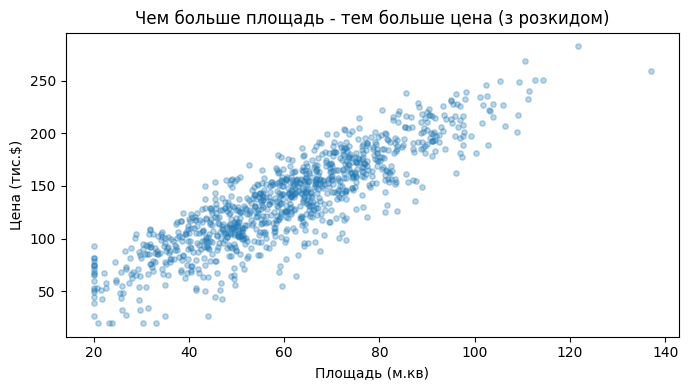

In [5]:
plt.figure(figsize=(7, 4))
plt.scatter(df['area'], df['price'], alpha=0.3, s=15)
plt.xlabel("Площадь (м.кв)")
plt.ylabel("Цена (тис.$)")
plt.title("Чем больше площадь - тем больше цена (з розкидом)")
plt.tight_layout()
plt.show()

В этом шаге я построил график, чтобы посмотреть, как связаны площадь квартиры и её цена. Использовал диаграмму рассеяния: по оси X отложена площадь, по оси Y - цена. Точки сделаны полупрозрачными, чтобы лучше видеть плотность данных. В итоге видно общую закономерность — чем больше площадь квартиры, тем выше цена, хотя есть небольшой разброс из-за случайных факторов в данных.

In [13]:
from sklearn.model_selection import train_test_split

X = df[['area','rooms', 'floor', 'dist_km', 'age_years']] #features - ознаки
y = df['price'] # target - цель

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print("Навчалльна вибірка", X_train.shape[0], "квартир")
print("Тестова вибірка", X_test.shape[0], "квартир")

Навчалльна вибірка 800 квартир
Тестова вибірка 200 квартир


В этом шаге я подготовил данные для обучения модели. Сначала разделил датасет на признаки (X) - это характеристики квартиры, такие как площадь, количество комнат, этаж, расстояние до центра и возраст дома и целевую переменную (y), то есть цену квартиры. Затем с помощью train_test_split разделил данные на обучающую и тестовую выборки: 80% данных пошло на обучение модели, а 20% - на проверку её качества. В конце вывел размеры обеих выборок, чтобы убедиться, что разделение прошло правильно.

## Линейная регрессия

In [15]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

compare = pd.DataFrame({
    "real_price": y_test[:5].round(2),
    "predict_price": y_pred[:5].round(2)
})

compare["error"] = (compare['predict_price'] - compare['real_price']).round(2)

compare

,real_price,predict_price,error
521,119.1,129.69,10.59
737,173.3,178.26,4.96
740,20.0,26.36,6.36
660,93.7,110.87,17.17
411,100.6,97.21,-3.39


В этом шаге я обучил простую модель линейной регрессии для прогнозирования цены квартир. Сначала создал и обучил модель на тренировочных данных (X_train, y_train), чтобы она нашла зависимость между характеристиками квартиры и её ценой. Затем сделал прогноз на тестовой выборке (X_test). После этого сравнил реальные и предсказанные значения для нескольких квартир, чтобы наглядно увидеть, насколько модель ошибается. В конце добавил столбец с ошибкой, чтобы оценить разницу между реальной и предсказанной ценой.

MAE - наскільки в середньому ми помилилися - 7 -> 7 тис. $

RMSE - схожу на MAE, сильніше карає великі промахи - менше = краще

R² - яку частину розкиду модель може оцінити - [0.;1.0] -> 1 - ідеально, 0 - вгадує середній показник

In [18]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print(f"MAE = {mae:.1f} тис. $ (в среднем на сколько ошибаемся)")
#print(f"MSE = {mse:.1f}")
print(f"RMSE = {rmse:.1f} тис. $ ")
print(f"R2= {r2:.3f} (модель объясняет) {r2 * 100:.1f}% роскиду цен")

MAE = 8.7 тис. $ (в среднем на сколько ошибаемся)
RMSE = 10.8 тис. $ 
R2= 0.947 (модель объясняет) 94.7% роскиду цен


В этом шаге я оценил качество модели с помощью основных метрик. Посчитал среднюю абсолютную ошибку (MAE), чтобы понять, насколько в среднем модель ошибается в предсказании цены. Также вычислил среднеквадратичную ошибку и её корень (RMSE), который сильнее штрафует большие ошибки и показывает более “жёсткую” оценку качества. В конце посчитал коэффициент детерминации R², который показывает, какую долю вариации цен модель вообще смогла объяснить. По сути, эти метрики помогают понять, насколько хорошо работает модель и можно ли ей доверять.

In [23]:
coefs = pd.DataFrame({
    "features": X.columns,
    "coef": model.coef_.round(2)
}).sort_values("coef", key=abs, ascending=False)

print(f"Базовая цена: {model.intercept_:.2f} тис. $\n")
print("Как каждая ознака впливае на цену")
coefs

Базовая цена: 40.83 тис. $

Как каждая ознака впливае на цену


,features,coef
1,rooms,5.22
3,dist_km,-3.07
0,area,1.78
4,age_years,-0.49
2,floor,0.39


В этом шаге я посмотрел, как каждая характеристика квартиры влияет на цену. Для этого я вывел коэффициенты линейной регрессии: они показывают, насколько изменяется цена при увеличении каждого признака на 1 единицу. Также я отсортировал признаки по важности, чтобы было проще понять, какие факторы сильнее всего влияют на стоимость. В конце вывел базовую цену это стартовая стоимость квартиры, от которой дальше уже добавляются или вычитаются влияния всех признаков.

In [ ]:
price2 = (
    40.83
    + area * 1.78
    + rooms * 5.22
    + dist_km * (-3.07)
    + age_years * (-0.49)
    + floor * (0.39)
).clip(20, None)

В этом шаге я собрал свою версию формулы цены, которую модель пытается выучить. Я взял те же признаки (площадь, комнаты, этаж, расстояние до центра и возраст дома) и задал им коэффициенты, которые примерно показывают, как каждый фактор влияет на цену. В итоге получил новую рассчитанную цену price2, которая немного отличается от исходной из-за округлений и упрощений.